In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
import shutil

sns.set()
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.5)
plt.rcParams['font.size'] = 18
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
USE_TEX = shutil.which('latex') is not None
plt.rcParams['text.usetex'] = USE_TEX
print(f"Matplotlib text rendering: {'LaTeX' if USE_TEX else 'mathtext fallback'}")

import torch
from torch import nn

from nflows.flows import Flow
from nflows.distributions import StandardNormal
from nflows.transforms import (
    CompositeTransform, InverseTransform,
    PiecewiseRationalQuadraticCouplingTransform,
    RandomPermutation,
    Sigmoid,
)

from Amplitude import DKpp, AmpSample, SquareDalitzPlot2
from DKpp import DKppCorrelated


Matplotlib text rendering: LaTeX


In [2]:
class MLP(nn.Module):
    def __init__(self, in_features, out_features,
                 hidden=64, layers=2, output_scale=0.30):
        super().__init__()
        feats = [nn.Linear(in_features, hidden), nn.SiLU()]
        for _ in range(layers - 1):
            feats += [nn.Linear(hidden, hidden), nn.SiLU()]
        self.backbone = nn.Sequential(*feats)
        self.head = nn.Linear(hidden, out_features)

        nn.init.zeros_(self.head.weight)
        nn.init.zeros_(self.head.bias)
        self.output_scale = output_scale

    def forward(self, x, context=None):
        h = self.backbone(x)
        return self.head(h) * self.output_scale


In [3]:
def create_flow(on_unit_box=True, num_flows=12, hidden_features=128,
                num_bins=24, device=None):
    """
    Create a rational-quadratic neural spline flow on [0,1]^2.
    Architecture matches the training notebooks exactly.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    dim = 2
    transforms = []

    if on_unit_box:
        sigmoid = Sigmoid()
        if hasattr(sigmoid, "temperature") and isinstance(sigmoid.temperature, torch.Tensor):
            sigmoid.temperature = sigmoid.temperature.to(device)
        if hasattr(sigmoid, "eps") and isinstance(sigmoid.eps, torch.Tensor):
            sigmoid.eps = sigmoid.eps.to(device)
        transforms.append(InverseTransform(sigmoid))

    masks = [torch.tensor([1, 0], dtype=torch.bool),
             torch.tensor([0, 1], dtype=torch.bool)]

    for i in range(num_flows):
        def _conditioner(in_f, out_f, _h=hidden_features):
            return MLP(in_f, out_f, hidden=_h, layers=2)

        transforms.append(
            PiecewiseRationalQuadraticCouplingTransform(
                mask=masks[i % 2],
                transform_net_create_fn=_conditioner,
                num_bins=num_bins,
                tails="linear",
                tail_bound=5.0,
                apply_unconditional_transform=False,
            )
        )
        transforms.append(RandomPermutation(features=dim))

    return Flow(
        transform=CompositeTransform(transforms),
        distribution=StandardNormal([dim]),
    )

def load_flow_state_compat(flow, path, map_location=None):
    """
    Load a flow checkpoint while tolerating the `Sigmoid.temperature` / `eps`
    buffer differences that can appear across `nflows` versions.
    """
    state = torch.load(path, map_location=map_location)
    model_state = flow.state_dict()

    missing = [k for k in model_state.keys() if k not in state]
    unexpected = [k for k in state.keys() if k not in model_state]

    allowed_tokens = ("temperature", "eps")
    bad_missing = [k for k in missing if not any(tok in k for tok in allowed_tokens)]
    bad_unexpected = [k for k in unexpected if not any(tok in k for tok in allowed_tokens)]
    if bad_missing or bad_unexpected:
        raise RuntimeError(
            "Checkpoint/model mismatch goes beyond the known Sigmoid buffer issue. "
            f"Missing: {bad_missing[:5]} Unexpected: {bad_unexpected[:5]}"
        )

    for key in missing:
        state[key] = model_state[key]
    for key in unexpected:
        state.pop(key)

    if missing or unexpected:
        print("Applied checkpoint compatibility fix:")
        if missing:
            print("  filled missing keys:", missing)
        if unexpected:
            print("  dropped unexpected keys:", unexpected)

    flow.load_state_dict(state, strict=False)
    return flow


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")


Using cpu device


In [5]:
# Symmetric-SDP plotting configuration.
# Switch FLOW_KIND to one of: "flavor", "even", "odd".
FLOW_KIND = "flavor"

# Keep these modest for a responsive first pass; increase if you want smoother plots.
N_TARGET = 1_000_000
N_SAMPLES = 1_000_000
N_NORM_GRID = 350
N_DENSITY_GRID = 250
N_MARGINAL_X = 400
N_MARGINAL_Y = 800
SLICE_VALUES = np.linspace(0.2, 0.8, 4)
SAVE_PREFIX = f"draft_figures_symmetric_{FLOW_KIND}"

# Symmetric SDP convention: the resonant pair is pi+ pi-, so m' is built from s23.
idx = (2, 3, 1)
mD, mKs, mpi = 1.86483, 0.497611, 0.13957018
sdp_obj = SquareDalitzPlot2(mD, mKs, mpi, mpi)
_sum_m2 = sdp_obj.mSq[0] + sdp_obj.mSq[1] + sdp_obj.mSq[2] + sdp_obj.mSq[3]

dkpp_flavor = DKpp()
dkpp_even = DKppCorrelated(cp=+1)
dkpp_odd = DKppCorrelated(cp=-1)

FLOW_CONFIG = {
    "flavor": {
        "title": r"Flavor $D^0$",
        "label": r"$|A_D|^2$",
        "ckpt": "flavor_SDP_sym_2e6/trial_seed1.pth",
        "exact_model": dkpp_flavor,
    },
    "even": {
        "title": r"CP-even $D_+$",
        "label": r"$|A_D + \bar A_D|^2 / 2$",
        "ckpt": "even_SDP_sym_2e6/trial_seed1.pth",
        "exact_model": dkpp_even,
    },
    "odd": {
        "title": r"CP-odd $D_-$",
        "label": r"$|A_D - \bar A_D|^2 / 2$",
        "ckpt": "odd_SDP_sym_2e6/trial_seed1.pth",
        "exact_model": dkpp_odd,
    },
}

cfg = FLOW_CONFIG[FLOW_KIND]
print(f"Plotting symmetric comparison for {cfg['title']} from {cfg['ckpt']}")


def _finite_pos(x, eps=1e-14):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    return np.maximum(x, eps)


def dp_to_sdp(points_dp, sdp_obj=sdp_obj, idx=idx):
    i, j, k = idx
    s12, s13 = points_dp[:, 0], points_dp[:, 1]
    s23 = _sum_m2 - s12 - s13
    mp = np.vectorize(lambda a, b: sdp_obj.MpfromM(a, b, i, j, k), otypes=[float])(s23, s12)
    tp = np.vectorize(lambda a, b: sdp_obj.TfromM(a, b, i, j, k), otypes=[float])(s23, s12)
    return np.column_stack([mp, tp])


def sdp_to_dp(points_sdp, sdp_obj=sdp_obj, idx=idx):
    i, j, k = idx
    out = np.empty_like(points_sdp, dtype=float)
    for n, (mp, tp) in enumerate(points_sdp):
        s23, s12 = sdp_obj.M_from_MpT(mp, tp, i, j, k)
        out[n, 0] = s12
        out[n, 1] = _sum_m2 - s23 - s12
    return out


def exact_sdp_density_raw(points_sdp, kind=FLOW_KIND):
    dp = sdp_to_dp(points_sdp, sdp_obj, idx)
    s12, s13 = dp[:, 0], dp[:, 1]
    s23 = _sum_m2 - s12 - s13

    amp = FLOW_CONFIG[kind]["exact_model"].full(np.column_stack([s12, s13]))
    i, j, k = idx
    J = np.array([
        float(sdp_obj.jacobian(s23[n], s12[n], i, j, k))
        for n in range(len(points_sdp))
    ])
    invJ = _finite_pos(1.0 / J)
    return np.abs(amp) ** 2 * invJ


_exact_norm_cache = {}


def exact_norm(kind=FLOW_KIND, n_grid=N_NORM_GRID):
    key = (kind, n_grid)
    if key not in _exact_norm_cache:
        eps = 1e-6
        u = np.linspace(eps, 1.0 - eps, n_grid)
        v = np.linspace(eps, 1.0 - eps, n_grid)
        U, V = np.meshgrid(u, v, indexing="xy")
        pts = np.column_stack([U.ravel(), V.ravel()])
        dens = exact_sdp_density_raw(pts, kind=kind).reshape(len(v), len(u))
        norm = np.trapz(np.trapz(dens, u, axis=1), v, axis=0)
        _exact_norm_cache[key] = norm
    return _exact_norm_cache[key]


def exact_sdp_density(points_sdp, kind=FLOW_KIND):
    return exact_sdp_density_raw(points_sdp, kind=kind) / exact_norm(kind=kind)


def sample_exact_sdp(n_samples=N_TARGET, kind=FLOW_KIND, seed=1234):
    np.random.seed(seed)
    sampler = AmpSample(FLOW_CONFIG[kind]["exact_model"])
    points_dp = sampler.generate(n_samples, nbatch=20_000)
    return dp_to_sdp(points_dp, sdp_obj, idx)


Plotting symmetric comparison for Flavor $D^0$ from flavor_SDP_sym_2e6/trial_seed1.pth


In [6]:
# Load the symmetric normalizing flow and generate an exact reference sample.
n_blocks = 12
n_bins = 24
hidden_features = 128

flow = create_flow(num_flows=n_blocks, hidden_features=hidden_features, num_bins=n_bins, device=device)
flow = load_flow_state_compat(flow, cfg["ckpt"], map_location=device)
flow = flow.to(device).eval()

total_params = sum(p.numel() for p in flow.parameters())
print(f"Total # of parameters: {total_params}")

mp_thetap = sample_exact_sdp(N_TARGET, kind=FLOW_KIND, seed=1234)
print(f"Loaded exact reference sample with {len(mp_thetap):,} events")


Applied checkpoint compatibility fix:
  filled missing keys: ['_transform._transforms.0._transform.temperature']
Total # of parameters: 311124
Loaded exact reference sample with 1,000,000 events


In [7]:
flow.eval()
flow.to(device)

with torch.no_grad():
    mp_thetap_gen = flow.sample(N_SAMPLES).cpu().numpy()

mp_thetap_gen = np.clip(mp_thetap_gen, 1e-6, 1.0 - 1e-6)
print(f"Generated {len(mp_thetap_gen):,} flow events")


/Users/san/opt/anaconda3/lib/python3.9/site-packages/nflows/transforms/coupling.py:561: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


Generated 1,000,000 flow events


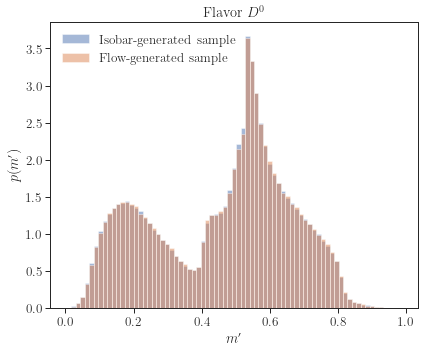

In [8]:
# Visualize m' projection
fig, ax = plt.subplots(figsize=(6, 5))
counts, bins, _ = ax.hist(
    mp_thetap[:, 0], 75, alpha=0.5, label='Isobar-generated events', density=True
)
ax.hist(
    mp_thetap_gen[:, 0], bins, alpha=0.5, label='Flow-generated events', density=True
)

ax.set_xlabel(r"$m'$")
ax.set_ylabel(r'$p(m^\prime)$')
ax.set_title(cfg["title"])
ax.legend(loc='best', frameon=False)
fig.tight_layout()


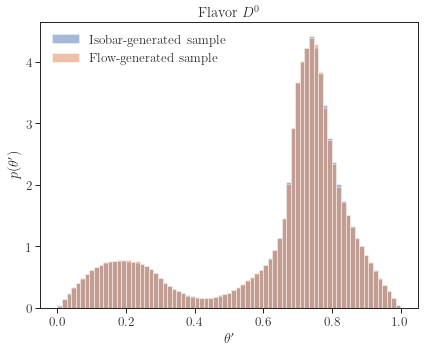

In [9]:
# Visualize theta' projection
fig, ax = plt.subplots(figsize=(6, 5))
counts, bins, _ = ax.hist(
    mp_thetap[:, 1], 75, alpha=0.5, label='Isobar-generated events', density=True
)
ax.hist(
    mp_thetap_gen[:, 1], bins, alpha=0.5, label='Flow-generated events', density=True
)

ax.set_xlabel(r"$\theta'$")
ax.set_ylabel(r'$p(\theta^\prime)$')
ax.set_title(cfg["title"])
ax.legend(loc='best', frameon=False)
fig.tight_layout()


/var/folders/k9/p5b9wydx1kn33thc8p74blx40000gn/T/ipykernel_73844/2138917260.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


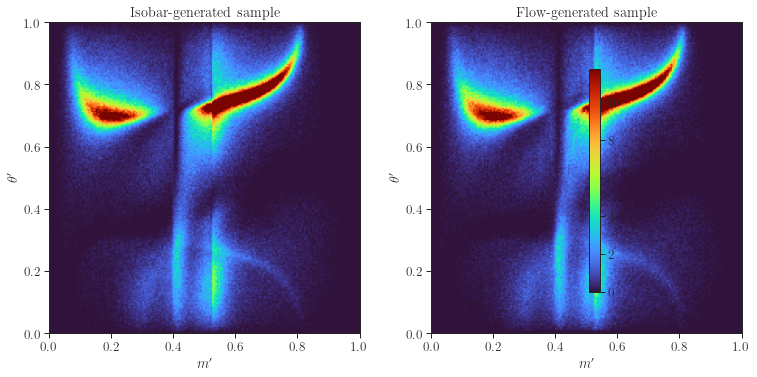

In [10]:
# Visualize the 2D SDP density with a common colour scale
xbins = np.linspace(0, 1, 201)
ybins = np.linspace(0, 1, 201)

h_exact, _, _ = np.histogram2d(mp_thetap[:, 0], mp_thetap[:, 1], bins=[xbins, ybins], density=True)
h_gen, _, _ = np.histogram2d(mp_thetap_gen[:, 0], mp_thetap_gen[:, 1], bins=[xbins, ybins], density=True)

vmax = np.nanpercentile(np.concatenate([h_exact.ravel(), h_gen.ravel()]), 99)
extent = [xbins[0], xbins[-1], ybins[0], ybins[-1]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 5))
im1 = ax1.imshow(h_exact.T, origin='lower', extent=extent, cmap='turbo', vmin=0.0, vmax=vmax, aspect='equal')
im2 = ax2.imshow(h_gen.T, origin='lower', extent=extent, cmap='turbo', vmin=0.0, vmax=vmax, aspect='equal')

ax1.set_title('Isobar-generated events')
ax2.set_title('Flow-generated events')
for ax in (ax1, ax2):
    ax.set_xlabel(r"$m'$")
    ax.set_ylabel(r"$\theta'$")

fig.colorbar(im2, ax=[ax1, ax2], shrink=0.82)
fig.tight_layout()


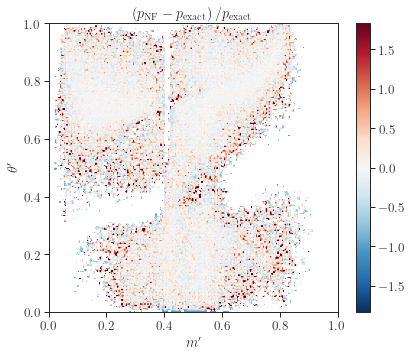

In [11]:
# Per-bin fractional difference, masking bins with negligible exact density
fig, ax = plt.subplots(figsize=(6, 5))
frac_diff = np.full_like(h_exact, np.nan)
mask = h_exact > np.nanpercentile(h_exact[h_exact > 0], 5)
frac_diff[mask] = (h_gen[mask] - h_exact[mask]) / h_exact[mask]

vlim = np.nanpercentile(np.abs(frac_diff[mask]), 98)
im = ax.imshow(
    frac_diff.T,
    origin='lower',
    extent=extent,
    cmap='RdBu_r',
    vmin=-vlim,
    vmax=vlim,
    aspect='equal',
)
ax.set_xlabel(r"$m'$")
ax.set_ylabel(r"$\theta'$")
ax.set_title(r'$\left(p_{\mathrm{NF}}-p_{\mathrm{exact}}\right) / p_{\mathrm{exact}}$')
fig.colorbar(im, ax=ax)
fig.tight_layout()


In [12]:
@torch.no_grad()
def marginal_likelihood(flow, axis=0, xs=None, nx=400, ny=800,
                        on_unit_box=True, eps=1e-8, data_range=None,
                        batch=65536, device=None):
    """
    Compute the 1D marginal learned by the flow along one SDP axis.
    axis=0 returns p(m'), axis=1 returns p(theta').
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    flow = flow.to(device).eval()

    if on_unit_box:
        xmin, xmax = eps, 1.0 - eps
        ymin, ymax = eps, 1.0 - eps
    else:
        if data_range is None:
            xmin, xmax = -3.0, 3.0
            ymin, ymax = -3.0, 3.0
        else:
            (xmin, xmax), (ymin, ymax) = data_range

    if xs is None:
        xs = np.linspace(xmin, xmax, nx, dtype=np.float32)
    else:
        xs = np.asarray(xs, dtype=np.float32)
        nx = xs.shape[0]

    ys = np.linspace(ymin, ymax, ny, dtype=np.float32)

    if axis == 0:
        XX = np.tile(xs, (ny, 1))
        YY = np.tile(ys[:, None], (1, nx))
    else:
        XX = np.tile(ys[:, None], (1, nx))
        YY = np.tile(xs, (ny, 1))

    grid = np.stack([XX.ravel(), YY.ravel()], axis=1).astype(np.float32)
    grid_t = torch.from_numpy(grid).to(device)

    outs = []
    for i in range(0, grid_t.shape[0], batch):
        outs.append(flow.log_prob(grid_t[i:i + batch]))
    logp = torch.cat(outs, dim=0).view(ny, nx)

    dy = (ymax - ymin) / (ny - 1)
    log_marg = torch.logsumexp(logp, dim=0) + torch.log(torch.tensor(dy, device=device))
    return xs, np.exp(log_marg.detach().cpu().numpy())


In [13]:
mprime_flow, dens_m_flow = marginal_likelihood(
    flow, axis=0, on_unit_box=True, nx=N_MARGINAL_X, ny=N_MARGINAL_Y, eps=1e-8, device=device
)
theta_flow, dens_theta_flow = marginal_likelihood(
    flow, axis=1, on_unit_box=True, nx=N_MARGINAL_X, ny=N_MARGINAL_Y, eps=1e-8, device=device
)

/Users/san/opt/anaconda3/lib/python3.9/site-packages/nflows/transforms/coupling.py:561: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


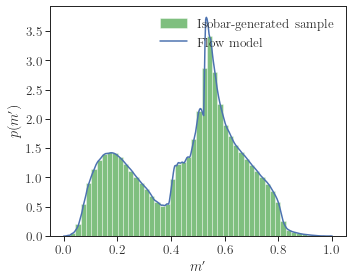

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.hist(mp_thetap[:, 0], 50, alpha=0.5, label='Isobar-generated events', density=True, color='green')
ax.plot(mprime_flow, dens_m_flow, lw=1.5, label='Flow model')
ax.legend(loc='best', frameon=False)
ax.set_xlabel(r"$m'$")
ax.set_ylabel(r'$p(m^\prime)$')
fig.tight_layout()


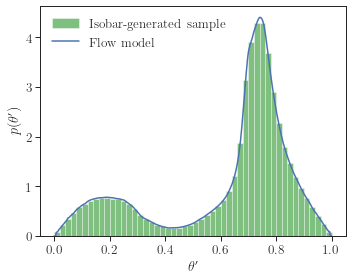

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.hist(mp_thetap[:, 1], 50, alpha=0.5, label='Isobar-generated events', density=True, color='green')
ax.plot(theta_flow, dens_theta_flow, lw=1.5, label='Flow model')
ax.legend(loc='best', frameon=False)
ax.set_xlabel(r"$\theta'$")
ax.set_ylabel(r'$p(\theta^\prime)$')
fig.tight_layout()


In [16]:
def exact_density_grid(kind=FLOW_KIND, n_grid=N_DENSITY_GRID, eps=1e-6):
    u = np.linspace(eps, 1.0 - eps, n_grid)
    v = np.linspace(eps, 1.0 - eps, n_grid)
    U, V = np.meshgrid(u, v, indexing='xy')
    pts = np.column_stack([U.ravel(), V.ravel()])
    dens = exact_sdp_density(pts, kind=kind).reshape(len(v), len(u))
    return u, v, dens


@torch.no_grad()
def flow_density_grid(flow, n_grid=N_DENSITY_GRID, eps=1e-6, batch=65536, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    u = np.linspace(eps, 1.0 - eps, n_grid, dtype=np.float32)
    v = np.linspace(eps, 1.0 - eps, n_grid, dtype=np.float32)
    U, V = np.meshgrid(u, v, indexing='xy')
    pts = np.column_stack([U.ravel(), V.ravel()]).astype(np.float32)
    pts_t = torch.from_numpy(pts).to(device)

    outs = []
    flow = flow.to(device).eval()
    for i in range(0, len(pts_t), batch):
        outs.append(flow.log_prob(pts_t[i:i + batch]))
    logp = torch.cat(outs, dim=0).cpu().numpy()
    return u, v, np.exp(logp).reshape(len(v), len(u))


mprime_exact, theta_exact, dens_exact_2d = exact_density_grid(FLOW_KIND)
_, _, dens_flow_2d = flow_density_grid(flow, device=device)

dens_m_exact = np.trapz(dens_exact_2d, theta_exact, axis=0)
dens_theta_exact = np.trapz(dens_exact_2d, mprime_exact, axis=1)


/Users/san/opt/anaconda3/lib/python3.9/site-packages/nflows/transforms/coupling.py:561: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


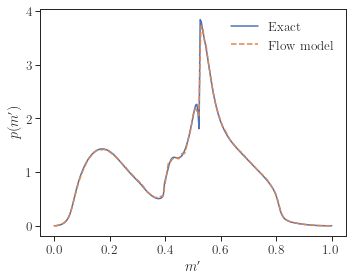

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.plot(mprime_exact, dens_m_exact, lw=1.5, label='Isobar model')
ax.plot(mprime_flow, dens_m_flow, '--', lw=1.5, label='Flow model')
ax.set_xlabel(r"$m'$")
ax.set_ylabel(r'$p(m^\prime)$')
ax.legend(loc='best', frameon=False)
fig.tight_layout()


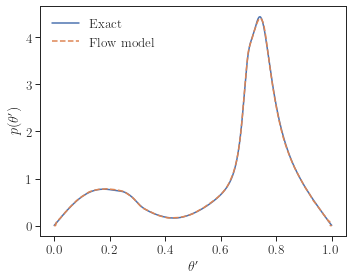

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.plot(theta_exact, dens_theta_exact, lw=1.5, label='Isobar model')
ax.plot(theta_flow, dens_theta_flow, '--', lw=1.5, label='Flow model')
ax.set_xlabel(r"$\theta'$")
ax.set_ylabel(r'$p(\theta^\prime)$')
ax.legend(loc='best', frameon=False)
fig.tight_layout()


In [19]:
@torch.no_grad()
def conditional_pdf(flow, fixed_value, fixed_axis=0, nx=400, on_unit_box=True,
                    eps=1e-8, data_range=None, batch=65536, device=None):
    """
    Return a normalized 1D conditional from the flow.
    fixed_axis=0: p(theta' | m' = fixed_value)
    fixed_axis=1: p(m' | theta' = fixed_value)
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    flow = flow.to(device).eval()

    if on_unit_box:
        xs = np.linspace(eps, 1.0 - eps, nx, dtype=np.float32)
    else:
        if data_range is None:
            xmin, xmax = -3.0, 3.0
        else:
            (xmin, xmax), _ = data_range
        xs = np.linspace(xmin, xmax, nx, dtype=np.float32)

    fixed = np.full_like(xs, fixed_value)
    if fixed_axis == 0:
        grid = np.column_stack([fixed, xs]).astype(np.float32)
    else:
        grid = np.column_stack([xs, fixed]).astype(np.float32)

    grid_t = torch.from_numpy(grid).to(device)
    outs = []
    for i in range(0, grid_t.shape[0], batch):
        outs.append(flow.log_prob(grid_t[i:i + batch]))
    logp = torch.cat(outs, dim=0).cpu().numpy()
    pdf = np.exp(logp)
    pdf = pdf / np.trapz(pdf, xs)
    return xs, pdf


In [20]:
def exact_conditional_theta_given_mprime(mprime, kind=FLOW_KIND, n_theta=400):
    theta = np.linspace(1e-6, 1.0 - 1e-6, n_theta)
    pts = np.column_stack([np.full_like(theta, mprime), theta])
    pdf = exact_sdp_density(pts, kind=kind)
    pdf = pdf / np.trapz(pdf, theta)
    return theta, pdf


def exact_conditional_mprime_given_theta(theta, kind=FLOW_KIND, n_mprime=400):
    mprime = np.linspace(1e-6, 1.0 - 1e-6, n_mprime)
    pts = np.column_stack([mprime, np.full_like(mprime, theta)])
    pdf = exact_sdp_density(pts, kind=kind)
    pdf = pdf / np.trapz(pdf, mprime)
    return mprime, pdf


/Users/san/opt/anaconda3/lib/python3.9/site-packages/nflows/transforms/coupling.py:561: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


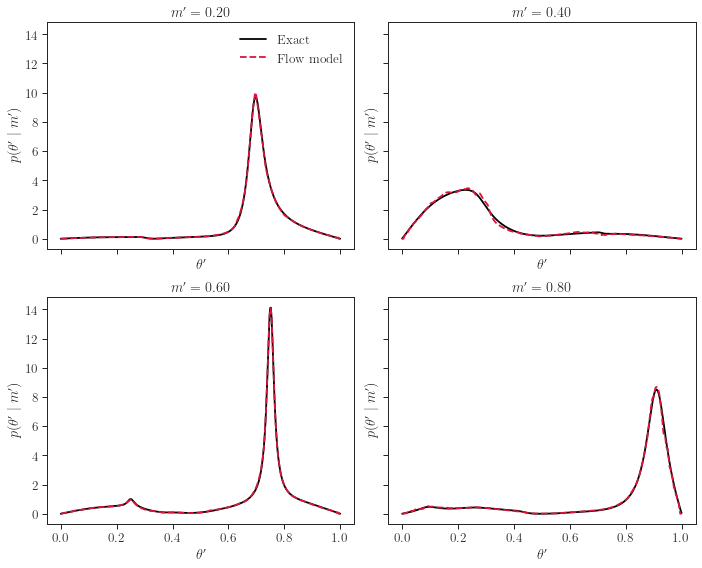

In [21]:
# Compare p(theta' | m') slices between the exact amplitude model and the symmetric flow
mprime_slices = SLICE_VALUES
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axs = axs.ravel()

for ax, m0 in zip(axs, mprime_slices):
    theta_ex, pdf_ex = exact_conditional_theta_given_mprime(m0, kind=FLOW_KIND)
    theta_nf, pdf_nf = conditional_pdf(flow, fixed_value=m0, fixed_axis=0, nx=400, device=device)

    ax.plot(theta_ex, pdf_ex, color='black', lw=1.8, label='Isobar model')
    ax.plot(theta_nf, pdf_nf, '--', color='crimson', lw=1.8, label='Flow model')
    ax.set_title(fr"$m' = {m0:.2f}$")
    ax.set_xlabel(r"$\theta'$")
    ax.set_ylabel(r'$p(\theta^\prime \mid m^\prime)$')

axs[0].legend(frameon=False)
fig.tight_layout()


/Users/san/opt/anaconda3/lib/python3.9/site-packages/nflows/transforms/coupling.py:561: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


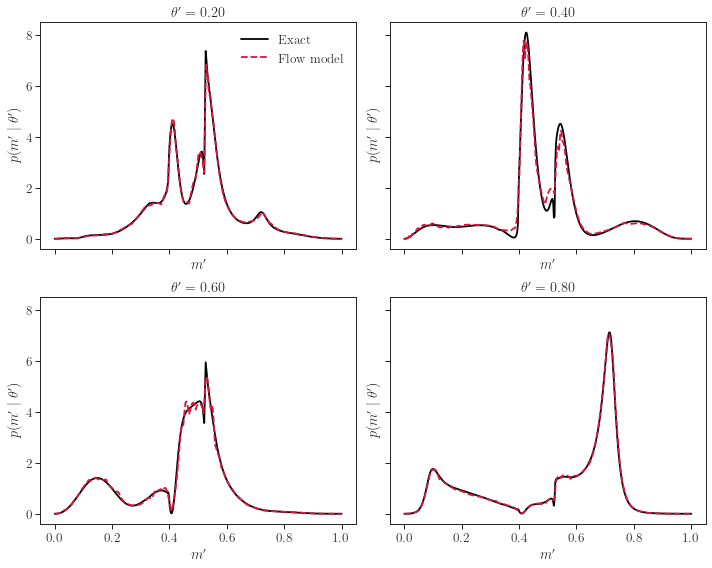

In [22]:
# Compare p(m' | theta') slices between the exact amplitude model and the symmetric flow
theta_slices = SLICE_VALUES
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axs = axs.ravel()

for ax, theta0 in zip(axs, theta_slices):
    m_ex, pdf_ex = exact_conditional_mprime_given_theta(theta0, kind=FLOW_KIND)
    m_nf, pdf_nf = conditional_pdf(flow, fixed_value=theta0, fixed_axis=1, nx=400, device=device)

    ax.plot(m_ex, pdf_ex, color='black', lw=1.8, label='Isobar model')
    ax.plot(m_nf, pdf_nf, '--', color='crimson', lw=1.8, label='Flow model')
    ax.set_title(fr"$\theta' = {theta0:.2f}$")
    ax.set_xlabel(r"$m'$")
    ax.set_ylabel(r'$p(m^\prime \mid \theta^\prime)$')

axs[0].legend(frameon=False)
fig.tight_layout()


In [72]:
from symmetric_figure_helpers import (
    plot_joint_marginals_density,
    plot_joint_marginals_samples,
    plot_conditionals_around_main,
)


def conditional_pdf_for_helpers(*, fixed_value, fixed_axis, nx=400):
    return conditional_pdf(
        flow,
        fixed_value=fixed_value,
        fixed_axis=fixed_axis,
        nx=nx,
        device=device,
    )


In [62]:
import importlib
import symmetric_figure_helpers
importlib.reload(symmetric_figure_helpers)

from symmetric_figure_helpers import (
    plot_joint_marginals_density,
    plot_joint_marginals_samples,
    plot_conditionals_around_main,
    plot_C_comparison_density,
    plot_absS_comparison_density,
    plot_S2_comparison_density,
)


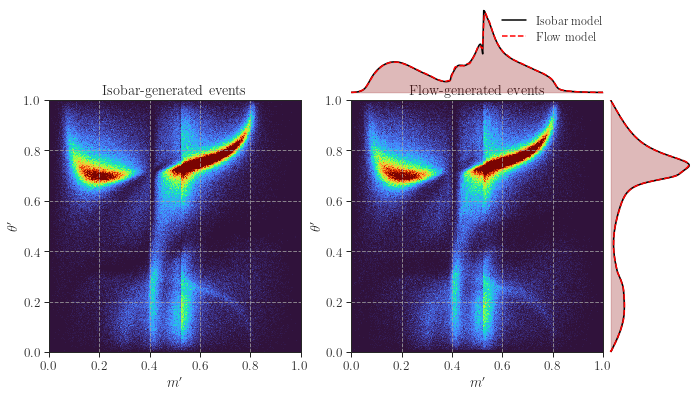

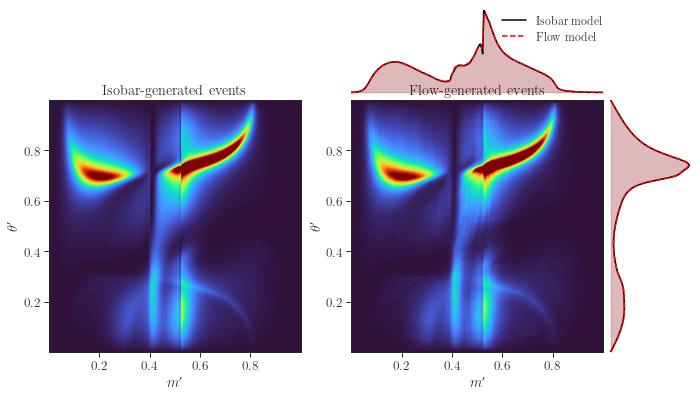

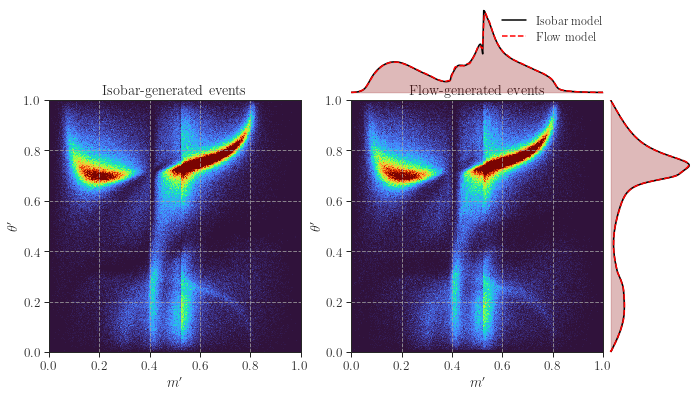

In [32]:
# Big comparison plots: density-map version and scatter-sample version
plot_joint_marginals_density(
    dens_exact_2d=dens_exact_2d,
    dens_flow_2d=dens_flow_2d,
    mprime_exact=mprime_exact,
    theta_exact=theta_exact,
    dens_m_exact=dens_m_exact,
    dens_theta_exact=dens_theta_exact,
    mprime_flow=mprime_flow,
    theta_flow=theta_flow,
    dens_m_flow=dens_m_flow,
    dens_theta_flow=dens_theta_flow,
    title_left="Isobar-generated events",
    title_right="Flow-generated events",
    sample_label=None,
    savepath=f"{SAVE_PREFIX}_joint_marginals_density.pdf",
)

plot_joint_marginals_samples(
    exact_samples=mp_thetap,
    flow_samples=mp_thetap_gen,
    mprime_exact=mprime_exact,
    theta_exact=theta_exact,
    dens_m_exact=dens_m_exact,
    dens_theta_exact=dens_theta_exact,
    mprime_flow=mprime_flow,
    theta_flow=theta_flow,
    dens_m_flow=dens_m_flow,
    dens_theta_flow=dens_theta_flow,
    title_left="Isobar-generated events",
    title_right="Flow-generated events",
    sample_label=None,
    savepath=f"{SAVE_PREFIX}_joint_marginals_scatter.pdf",
)


/Users/san/opt/anaconda3/lib/python3.9/site-packages/nflows/transforms/coupling.py:561: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


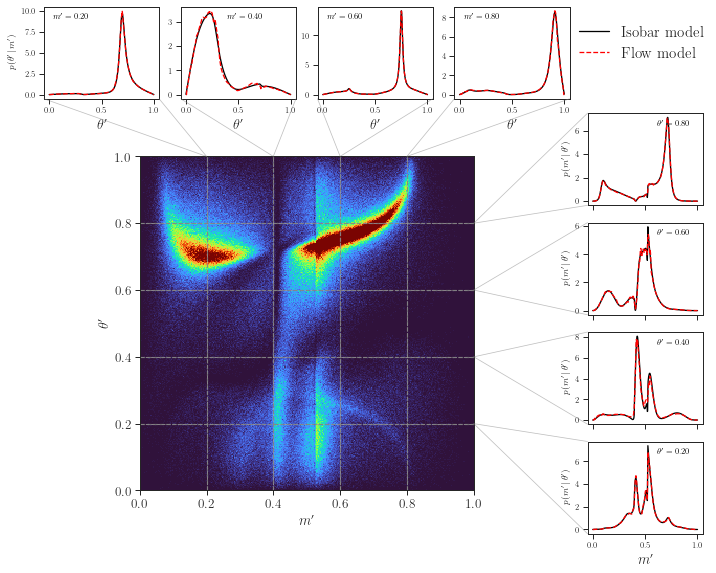

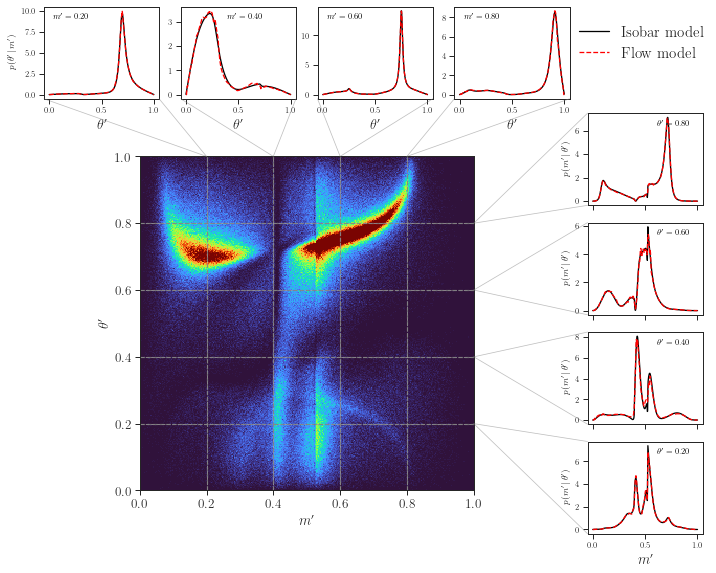

In [46]:
# Composite plot with the main SDP panel plus conditional-probability slices around it
plot_conditionals_around_main(
    exact_samples=mp_thetap,
    flow_samples=mp_thetap_gen,
    flow=flow,
    mprime_slices=mprime_slices,
    theta_slices=theta_slices,
    exact_conditional_theta_given_mprime=exact_conditional_theta_given_mprime,
    exact_conditional_mprime_given_theta=exact_conditional_mprime_given_theta,
    conditional_pdf_func=conditional_pdf_for_helpers,
    sample_label=None,
    savepath=f"{SAVE_PREFIX}_conditionals_around_main.pdf",
)


### Definition of `C(m', theta')`

In this notebook, `C` is the **physical interference term** in Square Dalitz Plot coordinates, not the normalized cosine-like correlation.

We use
$$
\bar A_D(s_{12}, s_{13}) = A_D(s_{13}, s_{12}),
$$
so that
$$
C(s_{12}, s_{13}) = \mathrm{Re}\bigl[A_D(s_{12}, s_{13}) \bar A_D^*(s_{12}, s_{13})\bigr].
$$

With the CP-eigenstate amplitudes
$$
A_{D_{\pm}} = \frac{A_D \pm \bar A_D}{\sqrt{2}},
$$
we have
$$
|A_{D_+}|^2 - |A_{D_-}|^2 = 2 \, \mathrm{Re}(A_D \bar A_D^*) = 2C.
$$

In the SDP convention used here, the plotted quantity is the **differential, Jacobian-weighted** version,
$$
C(m',\theta') = \frac{4 \, \mathrm{Re}(A_D \bar A_D^*)}{\Gamma_+ + \Gamma_-} \, \frac{1}{J_{\mathrm{SDP}}},
$$
which is exactly what is compared against the flow-based extraction
$$
C_{\mathrm{flow}}(m',\theta') = \frac{\Gamma_+ \, p_+(m',\theta') - \Gamma_- \, p_-(m',\theta')}{\Gamma_+ + \Gamma_-}.
$$

Because swapping the two pions sends
$$
(s_{12}, s_{13}) \leftrightarrow (s_{13}, s_{12}),
$$
and in the symmetric SDP convention this is simply
$$
(m', \theta') \to (m', 1-\theta'),
$$
`C` is symmetric under that transformation:
$$
C(m', \theta') = C(m', 1-\theta').
$$


In [42]:
# C(m', theta') comparison in the symmetric SDP convention

def make_sdp_grid(nx=400, ny=400, eps=1e-6):
    u = np.linspace(eps, 1.0 - eps, nx)
    v = np.linspace(eps, 1.0 - eps, ny)
    U, V = np.meshgrid(u, v, indexing='xy')
    pts = np.column_stack([U.ravel(), V.ravel()])
    return U, V, pts


def compute_Gamma_pm_sym(dkpp_model=dkpp_flavor, sdp_obj=sdp_obj, idx=idx, n_grid=500):
    u = np.linspace(1e-6, 1.0 - 1e-6, n_grid)
    v = np.linspace(1e-6, 1.0 - 1e-6, n_grid)
    U, V = np.meshgrid(u, v, indexing='xy')
    pts = np.column_stack([U.ravel(), V.ravel()])

    dp = sdp_to_dp(pts, sdp_obj, idx)
    s12, s13 = dp[:, 0], dp[:, 1]
    s23 = _sum_m2 - s12 - s13

    A12 = dkpp_model.full(np.column_stack([s12, s13]))
    A13s = dkpp_model.full(np.column_stack([s13, s12]))

    I_plus = np.abs(A12 + A13s) ** 2
    I_minus = np.abs(A12 - A13s) ** 2

    i, j, k = idx
    J = np.array([float(sdp_obj.jacobian(s23[n], s12[n], i, j, k)) for n in range(len(pts))])
    invJ = _finite_pos(1.0 / J)

    dA = (1.0 / (n_grid - 1)) ** 2
    Gamma_plus = np.sum(I_plus * invJ) * dA
    Gamma_minus = np.sum(I_minus * invJ) * dA
    return Gamma_plus, Gamma_minus


@torch.no_grad()
def pdf_from_flow(pts, flow, device=device, batch=65536):
    pts_t = torch.from_numpy(np.asarray(pts, dtype=np.float32)).to(device)
    outs = []
    flow = flow.to(device).eval()
    for i in range(0, len(pts_t), batch):
        outs.append(flow.log_prob(pts_t[i:i + batch]))
    logp = torch.cat(outs, dim=0).cpu().numpy()
    return np.exp(logp)


def compute_C_exact_sym(pts, dkpp_model=dkpp_flavor, sdp_obj=sdp_obj, idx=idx,
                        Gamma_plus=None, Gamma_minus=None):
    if Gamma_plus is None or Gamma_minus is None:
        Gamma_plus, Gamma_minus = compute_Gamma_pm_sym(dkpp_model=dkpp_model, sdp_obj=sdp_obj, idx=idx)

    dp = sdp_to_dp(pts, sdp_obj, idx)
    s12, s13 = dp[:, 0], dp[:, 1]
    s23 = _sum_m2 - s12 - s13
    i, j, k = idx
    J = np.array([float(sdp_obj.jacobian(s23[n], s12[n], i, j, k)) for n in range(len(pts))])
    invJ = _finite_pos(1.0 / J)

    A12 = dkpp_model.full(np.column_stack([s12, s13]))
    A13s = dkpp_model.full(np.column_stack([s13, s12]))
    return 4.0 * np.real(A12 * np.conjugate(A13s)) * invJ / (Gamma_plus + Gamma_minus)


def compute_C_flow_sym(pts, flow_even, flow_odd, Gamma_plus, Gamma_minus, device=device):
    f_even = pdf_from_flow(pts, flow_even, device=device)
    f_odd = pdf_from_flow(pts, flow_odd, device=device)
    return (Gamma_plus * f_even - Gamma_minus * f_odd) / (Gamma_plus + Gamma_minus)


flow_even_C = create_flow(num_flows=12, hidden_features=128, num_bins=24, device=device)
flow_even_C = load_flow_state_compat(flow_even_C, FLOW_CONFIG['even']['ckpt'], map_location=device)
flow_even_C = flow_even_C.to(device).eval()

flow_odd_C = create_flow(num_flows=12, hidden_features=128, num_bins=24, device=device)
flow_odd_C = load_flow_state_compat(flow_odd_C, FLOW_CONFIG['odd']['ckpt'], map_location=device)
flow_odd_C = flow_odd_C.to(device).eval()

Gamma_plus_C, Gamma_minus_C = compute_Gamma_pm_sym()
print(f'Gamma_+ = {Gamma_plus_C:.6f}')
print(f'Gamma_- = {Gamma_minus_C:.6f}')

U_C, V_C, pts_C = make_sdp_grid(nx=400, ny=400)
C_exact = compute_C_exact_sym(pts_C, Gamma_plus=Gamma_plus_C, Gamma_minus=Gamma_minus_C)
C_flow = compute_C_flow_sym(pts_C, flow_even_C, flow_odd_C, Gamma_plus_C, Gamma_minus_C)

NY_C, NX_C = U_C.shape
C_exact_img = C_exact.reshape(NY_C, NX_C)
C_flow_img = C_flow.reshape(NY_C, NX_C)


Applied checkpoint compatibility fix:
  filled missing keys: ['_transform._transforms.0._transform.temperature']
Applied checkpoint compatibility fix:
  filled missing keys: ['_transform._transforms.0._transform.temperature']
Gamma_+ = 949.677261
Gamma_- = 2008.213303


/Users/san/opt/anaconda3/lib/python3.9/site-packages/nflows/transforms/coupling.py:561: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


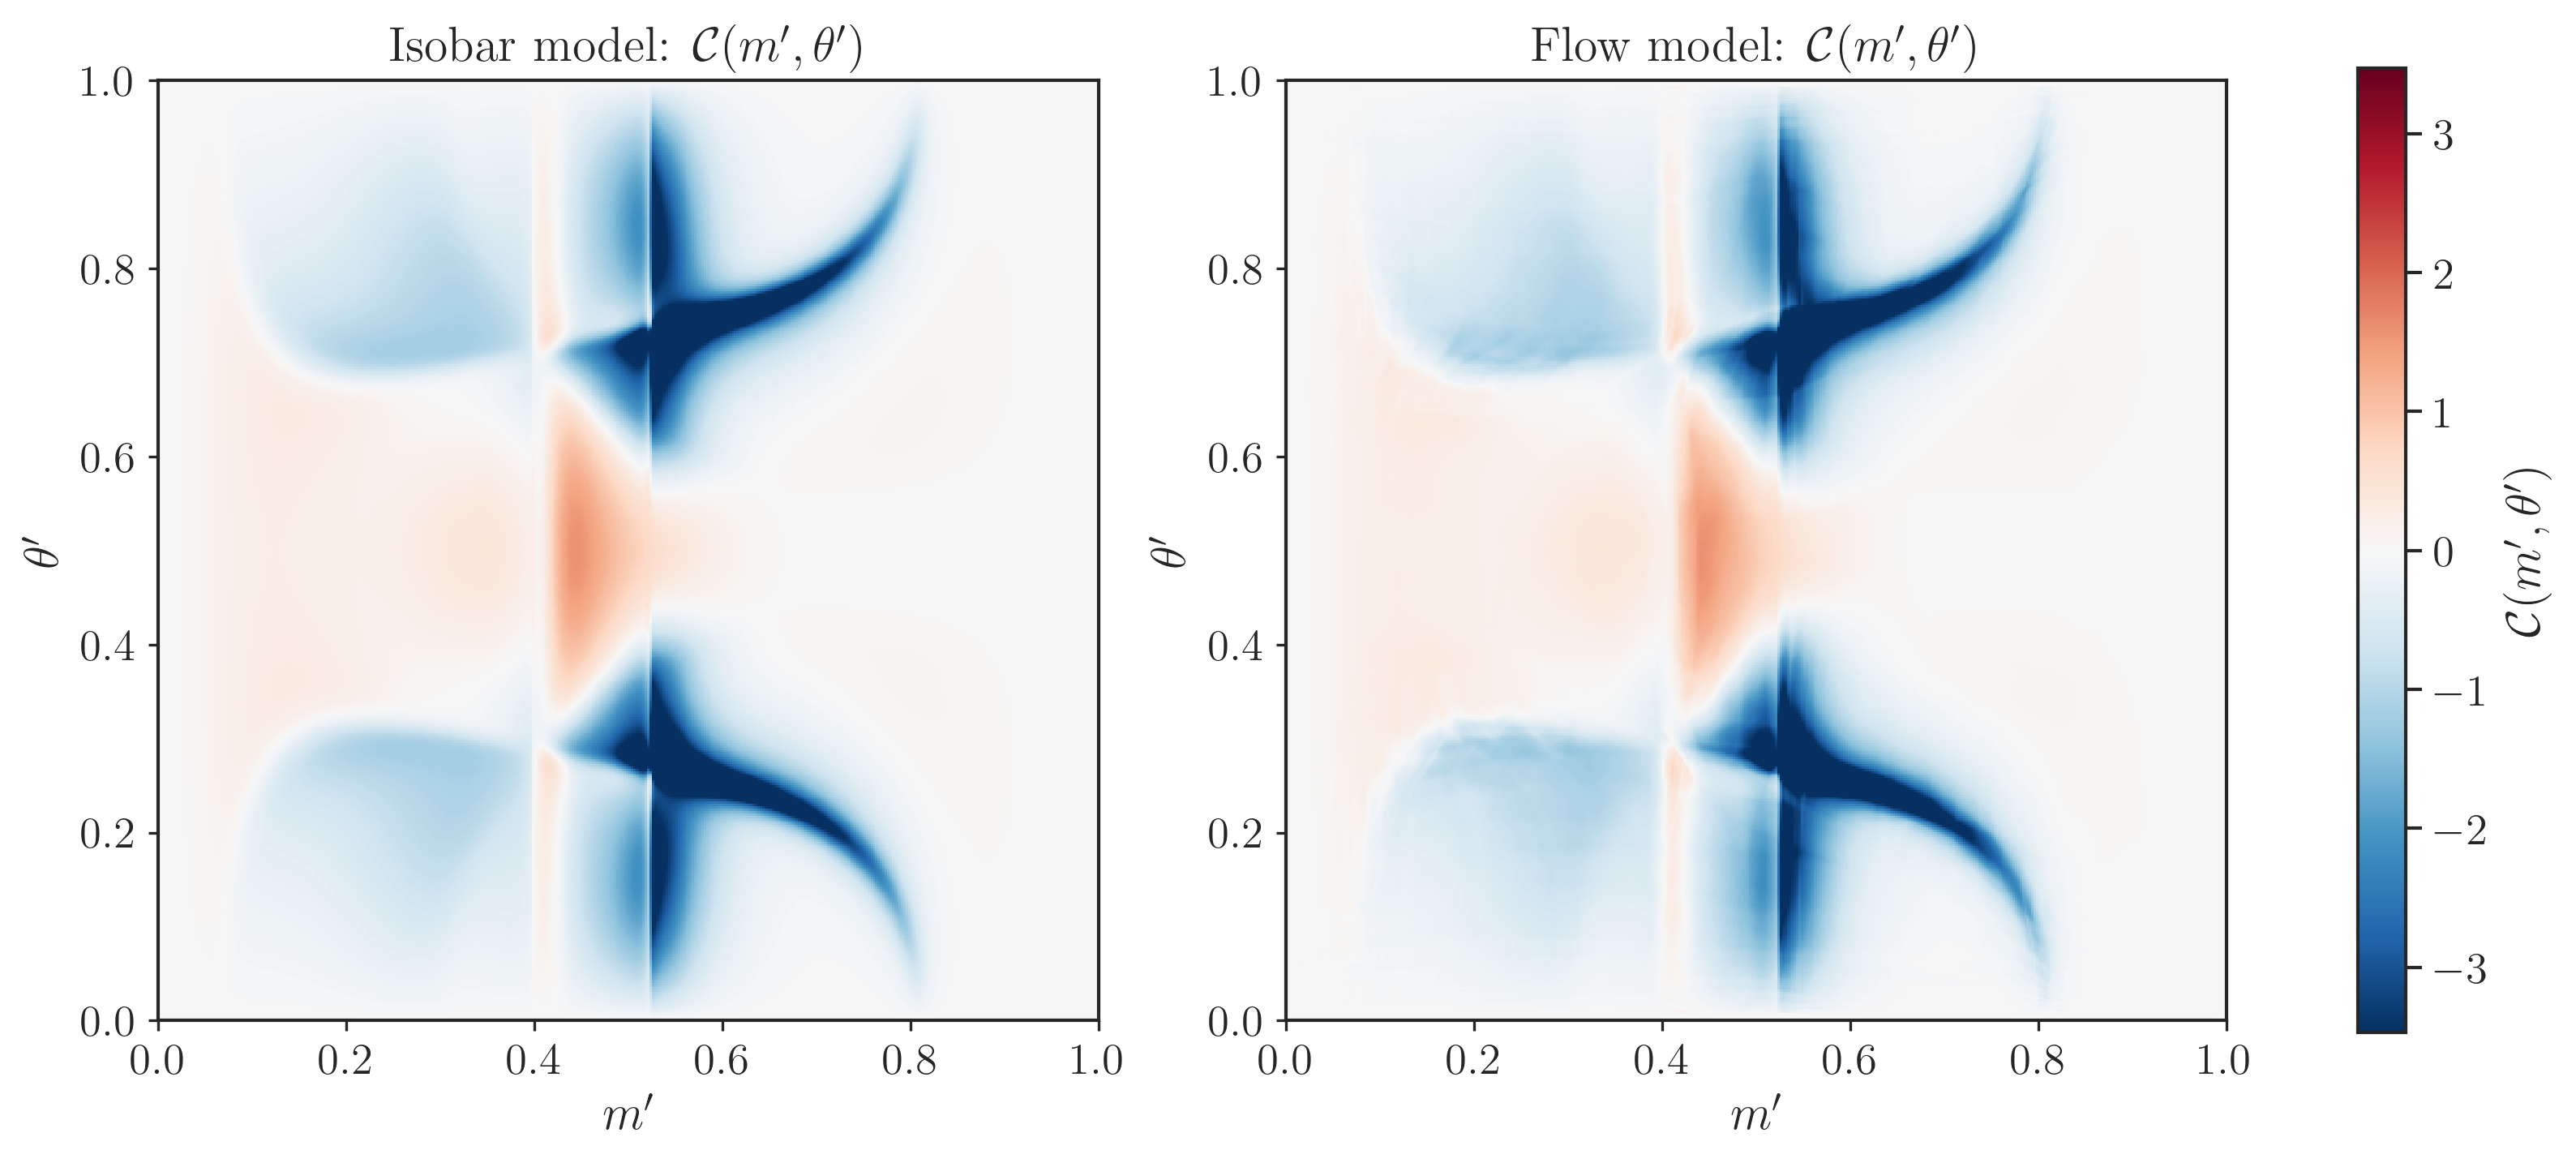

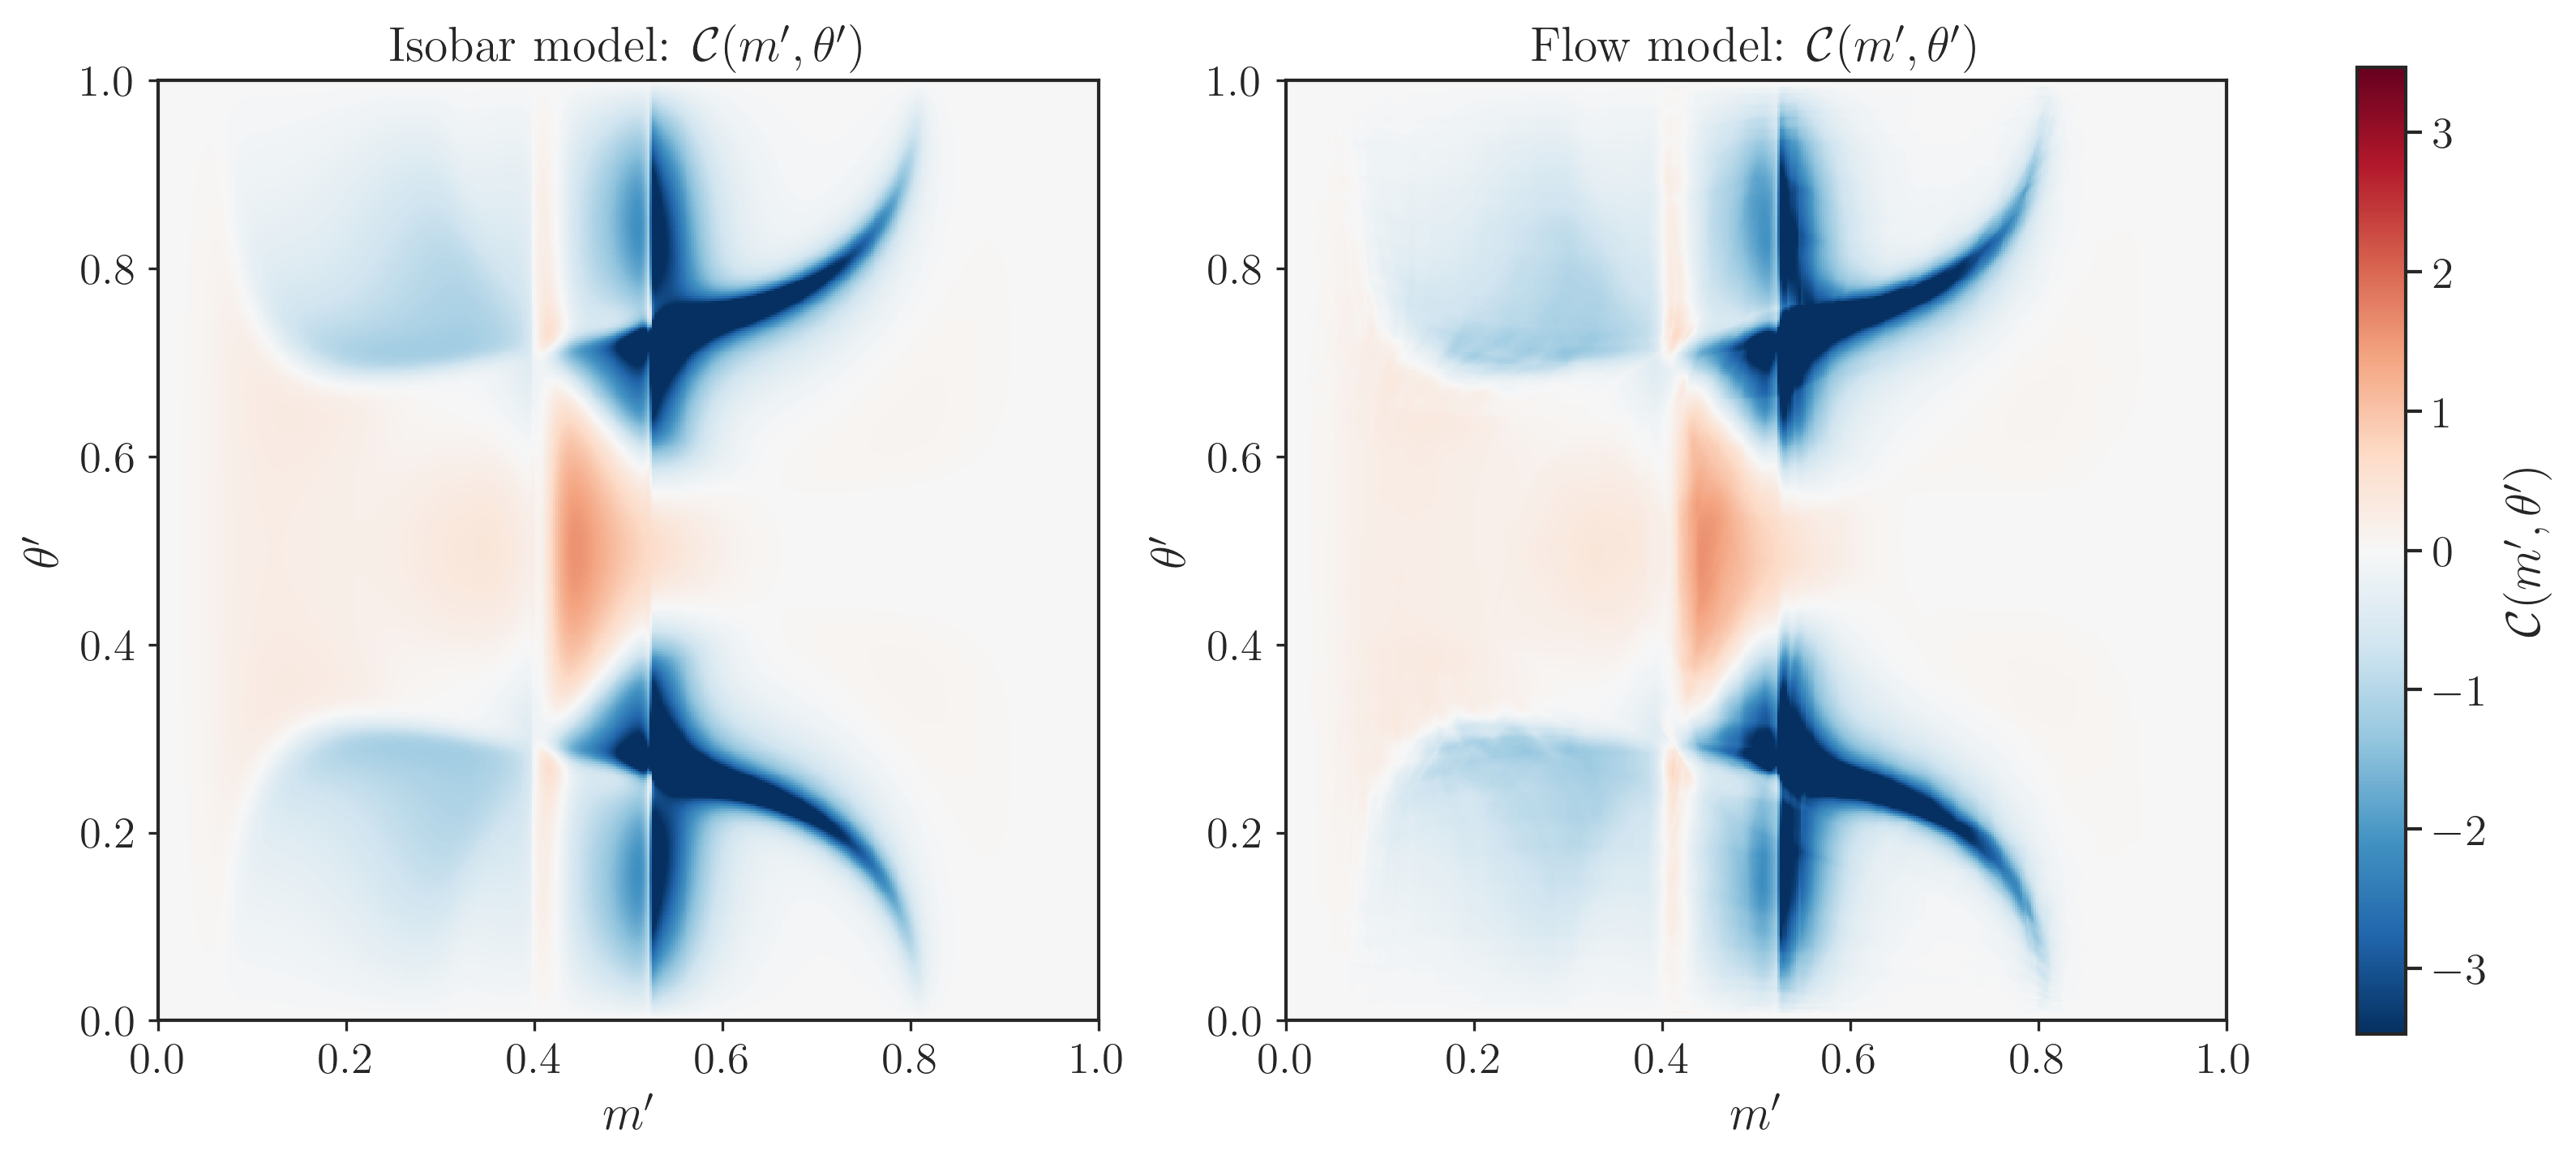

In [48]:
plot_C_comparison_density(
    C_exact=C_exact_img,
    C_flow=C_flow_img,
    extent=(0.0, 1.0, 0.0, 1.0),
    savepath='C_comparison_mtheta_symmetric.pdf',
)


### Definition of `|S(m', theta')|` used here

$$
|S(m',\theta')| = \sqrt{\max\left(0, K(m',\theta')\,\overline{K}(m',\theta') - C(m',\theta')^2\right)}.
$$

Here `K` and `\overline{K}` are the flavor densities at `(m', \theta')` and at the swapped point `(m', 1-\theta')`.
The `max(0, ...)` clipping is applied numerically before taking the square root.


In [ ]:
# |S(m', theta')| comparison using |S| = sqrt(K Kbar - C^2)
pts_S = pts_C
pts_S_swap = pts_S.copy()
pts_S_swap[:, 1] = 1.0 - pts_S_swap[:, 1]

K_exact = exact_sdp_density(pts_S, kind='flavor')
Kbar_exact = exact_sdp_density(pts_S_swap, kind='flavor')
absS_exact = np.sqrt(np.clip(K_exact * Kbar_exact - C_exact**2, 0.0, None))

flow_flavor_S = create_flow(num_flows=12, hidden_features=128, num_bins=24, device=device)
flow_flavor_S = load_flow_state_compat(flow_flavor_S, FLOW_CONFIG['flavor']['ckpt'], map_location=device)
flow_flavor_S = flow_flavor_S.to(device).eval()

K_flow = pdf_from_flow(pts_S, flow_flavor_S, device=device)
Kbar_flow = pdf_from_flow(pts_S_swap, flow_flavor_S, device=device)
absS_flow = np.sqrt(np.clip(K_flow * Kbar_flow - C_flow**2, 0.0, None))

NY_S, NX_S = U_C.shape
absS_exact_img = absS_exact.reshape(NY_S, NX_S)
absS_flow_img = absS_flow.reshape(NY_S, NX_S)


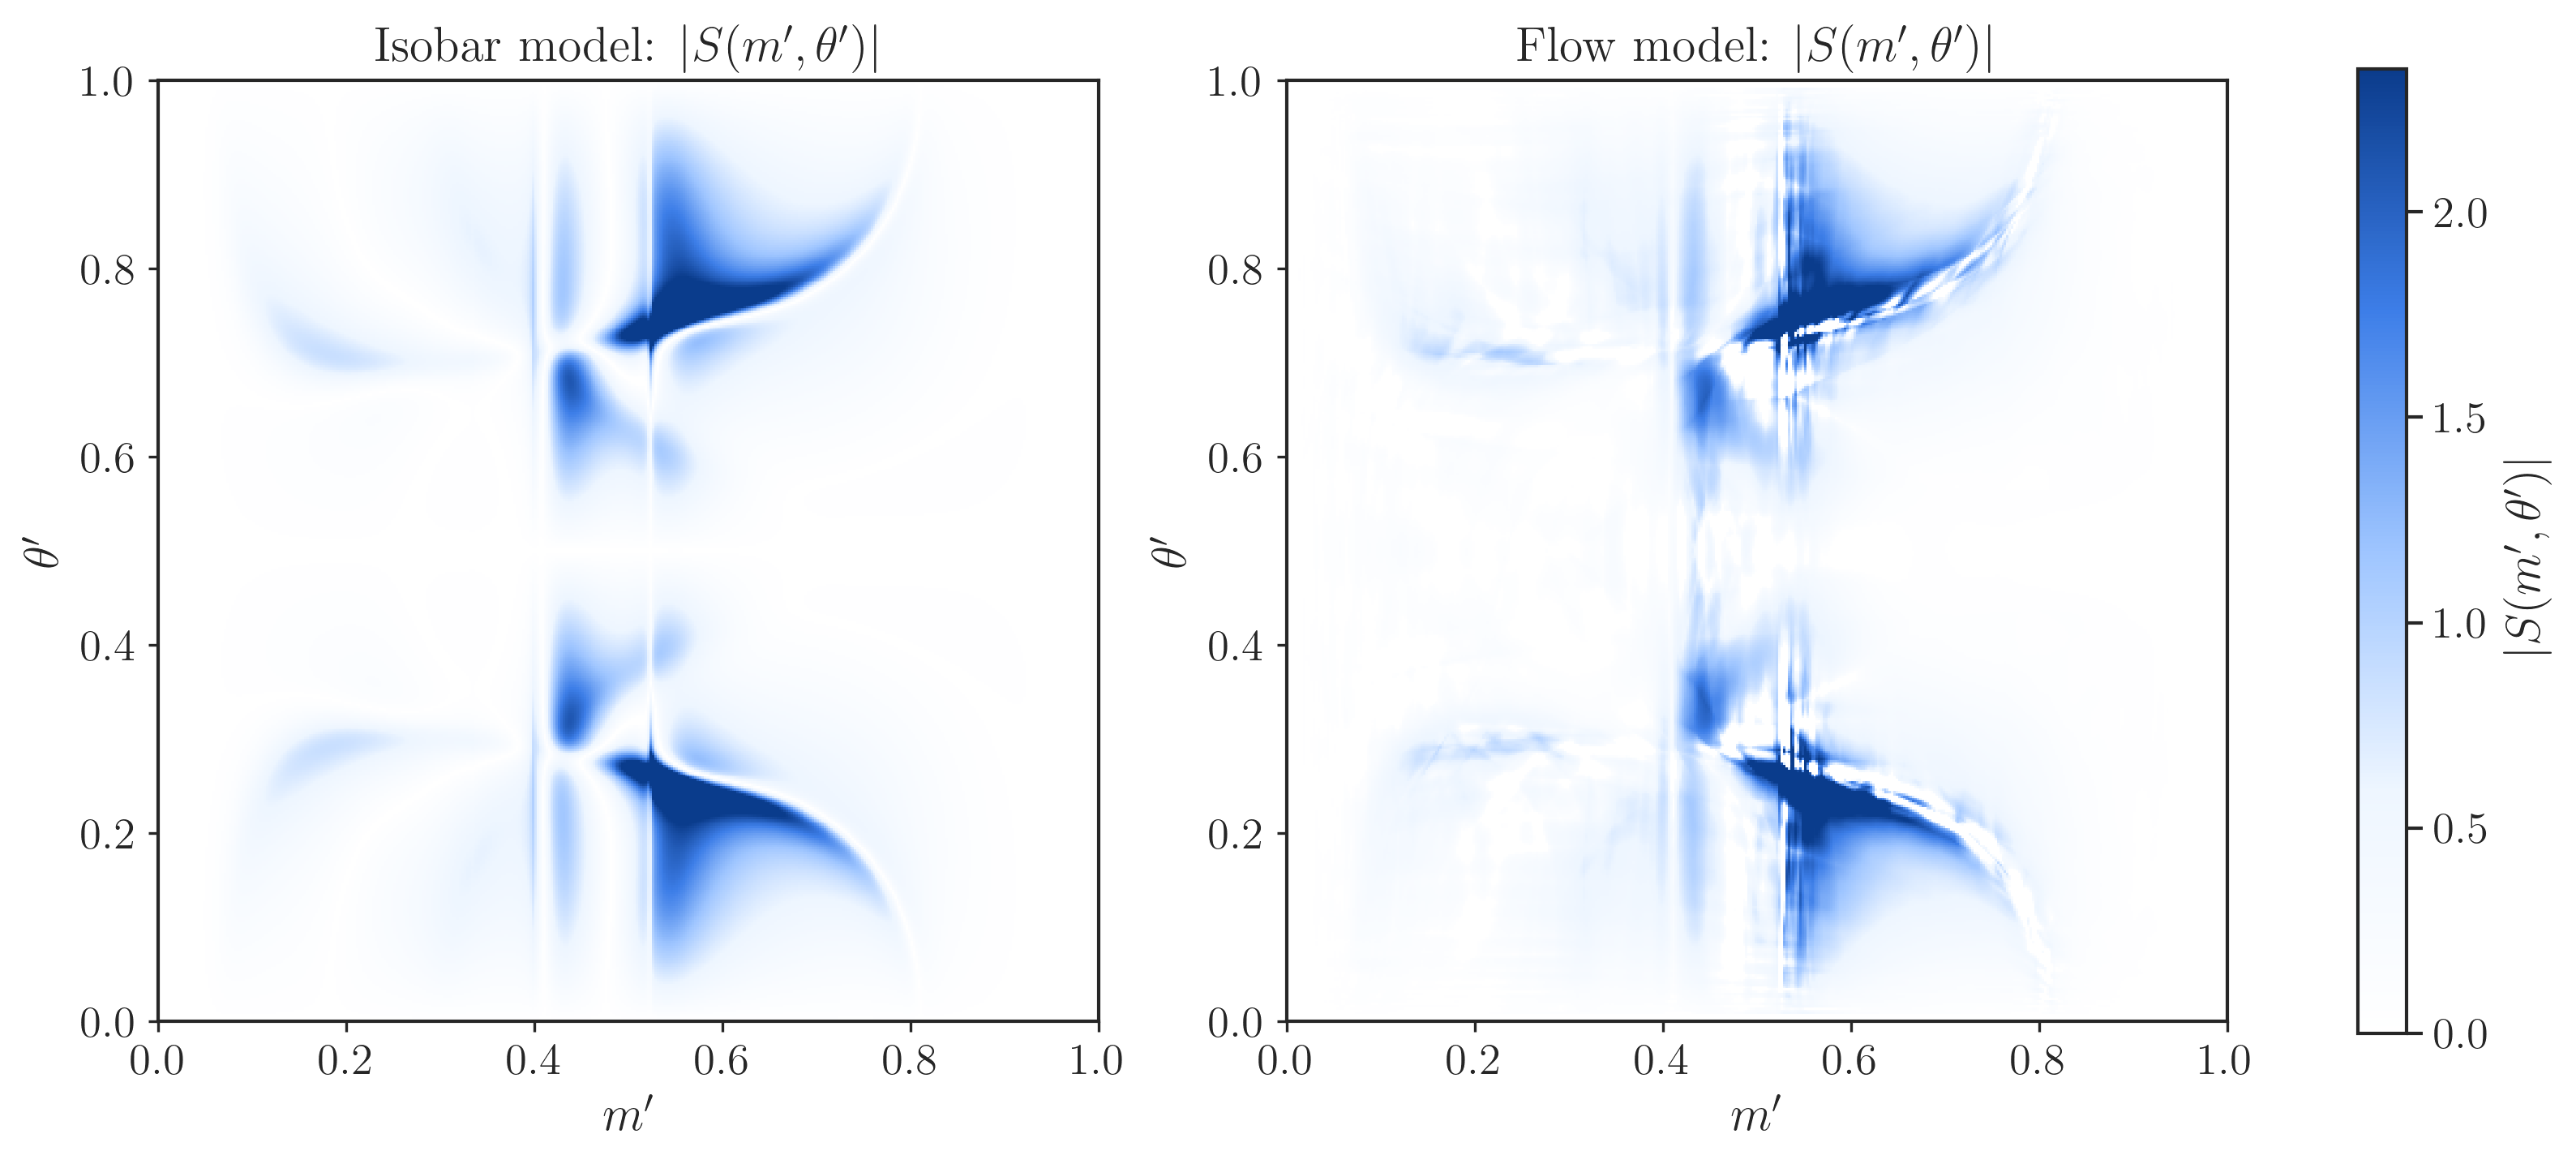

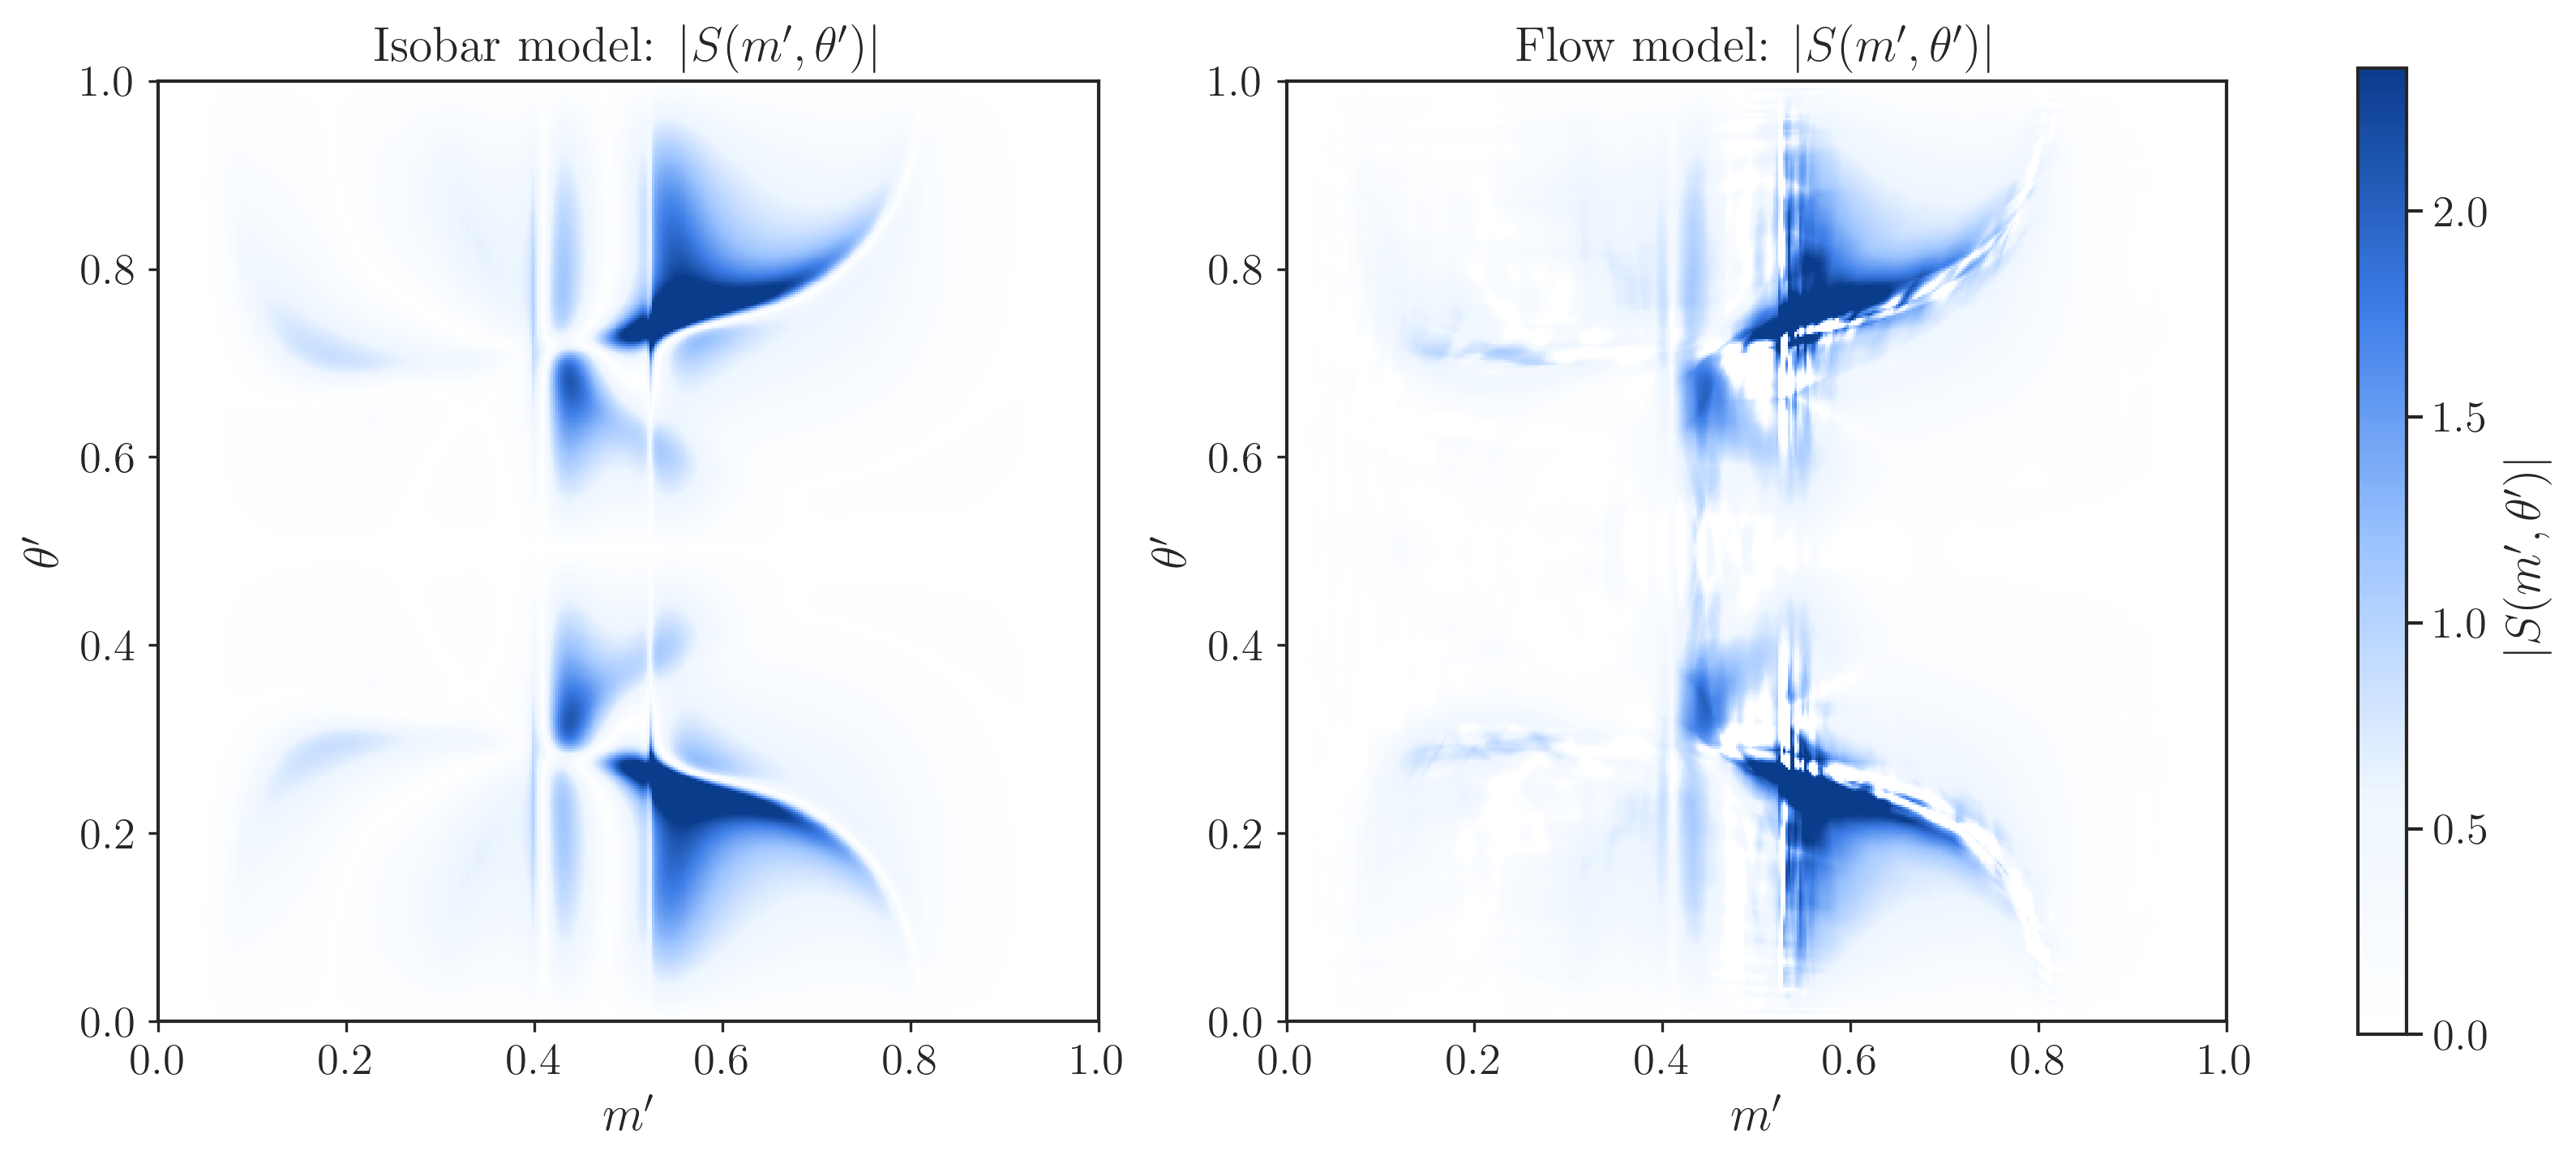

In [66]:
plot_absS_comparison_density(
    S_exact=absS_exact_img,
    S_flow=absS_flow_img,
    extent=(0.0, 1.0, 0.0, 1.0),
    savepath='absS_comparison_mtheta_symmetric.pdf',
)


### Additional plot: raw $S^2(m', \theta')$

This shows the unclipped quantity
$$
S^2(m',\theta') = K(m',\theta')\,\overline{K}(m',\theta') - C(m',\theta')^2,
$$
so negative regions are displayed explicitly instead of being removed by the square root.


In [70]:
# Raw S^2(m', theta') = K Kbar - C^2 comparison
S2_exact = K_exact * Kbar_exact - C_exact**2
S2_flow = K_flow * Kbar_flow - C_flow**2

NY_S2, NX_S2 = U_C.shape
S2_exact_img = S2_exact.reshape(NY_S2, NX_S2)
S2_flow_img = S2_flow.reshape(NY_S2, NX_S2)


In [74]:
import importlib
import symmetric_figure_helpers
importlib.reload(symmetric_figure_helpers)

plot_joint_marginals_density = symmetric_figure_helpers.plot_joint_marginals_density
plot_joint_marginals_samples = symmetric_figure_helpers.plot_joint_marginals_samples
plot_conditionals_around_main = symmetric_figure_helpers.plot_conditionals_around_main
plot_C_comparison_density = symmetric_figure_helpers.plot_C_comparison_density
plot_absS_comparison_density = symmetric_figure_helpers.plot_absS_comparison_density
plot_S2_comparison_density = symmetric_figure_helpers.plot_S2_comparison_density


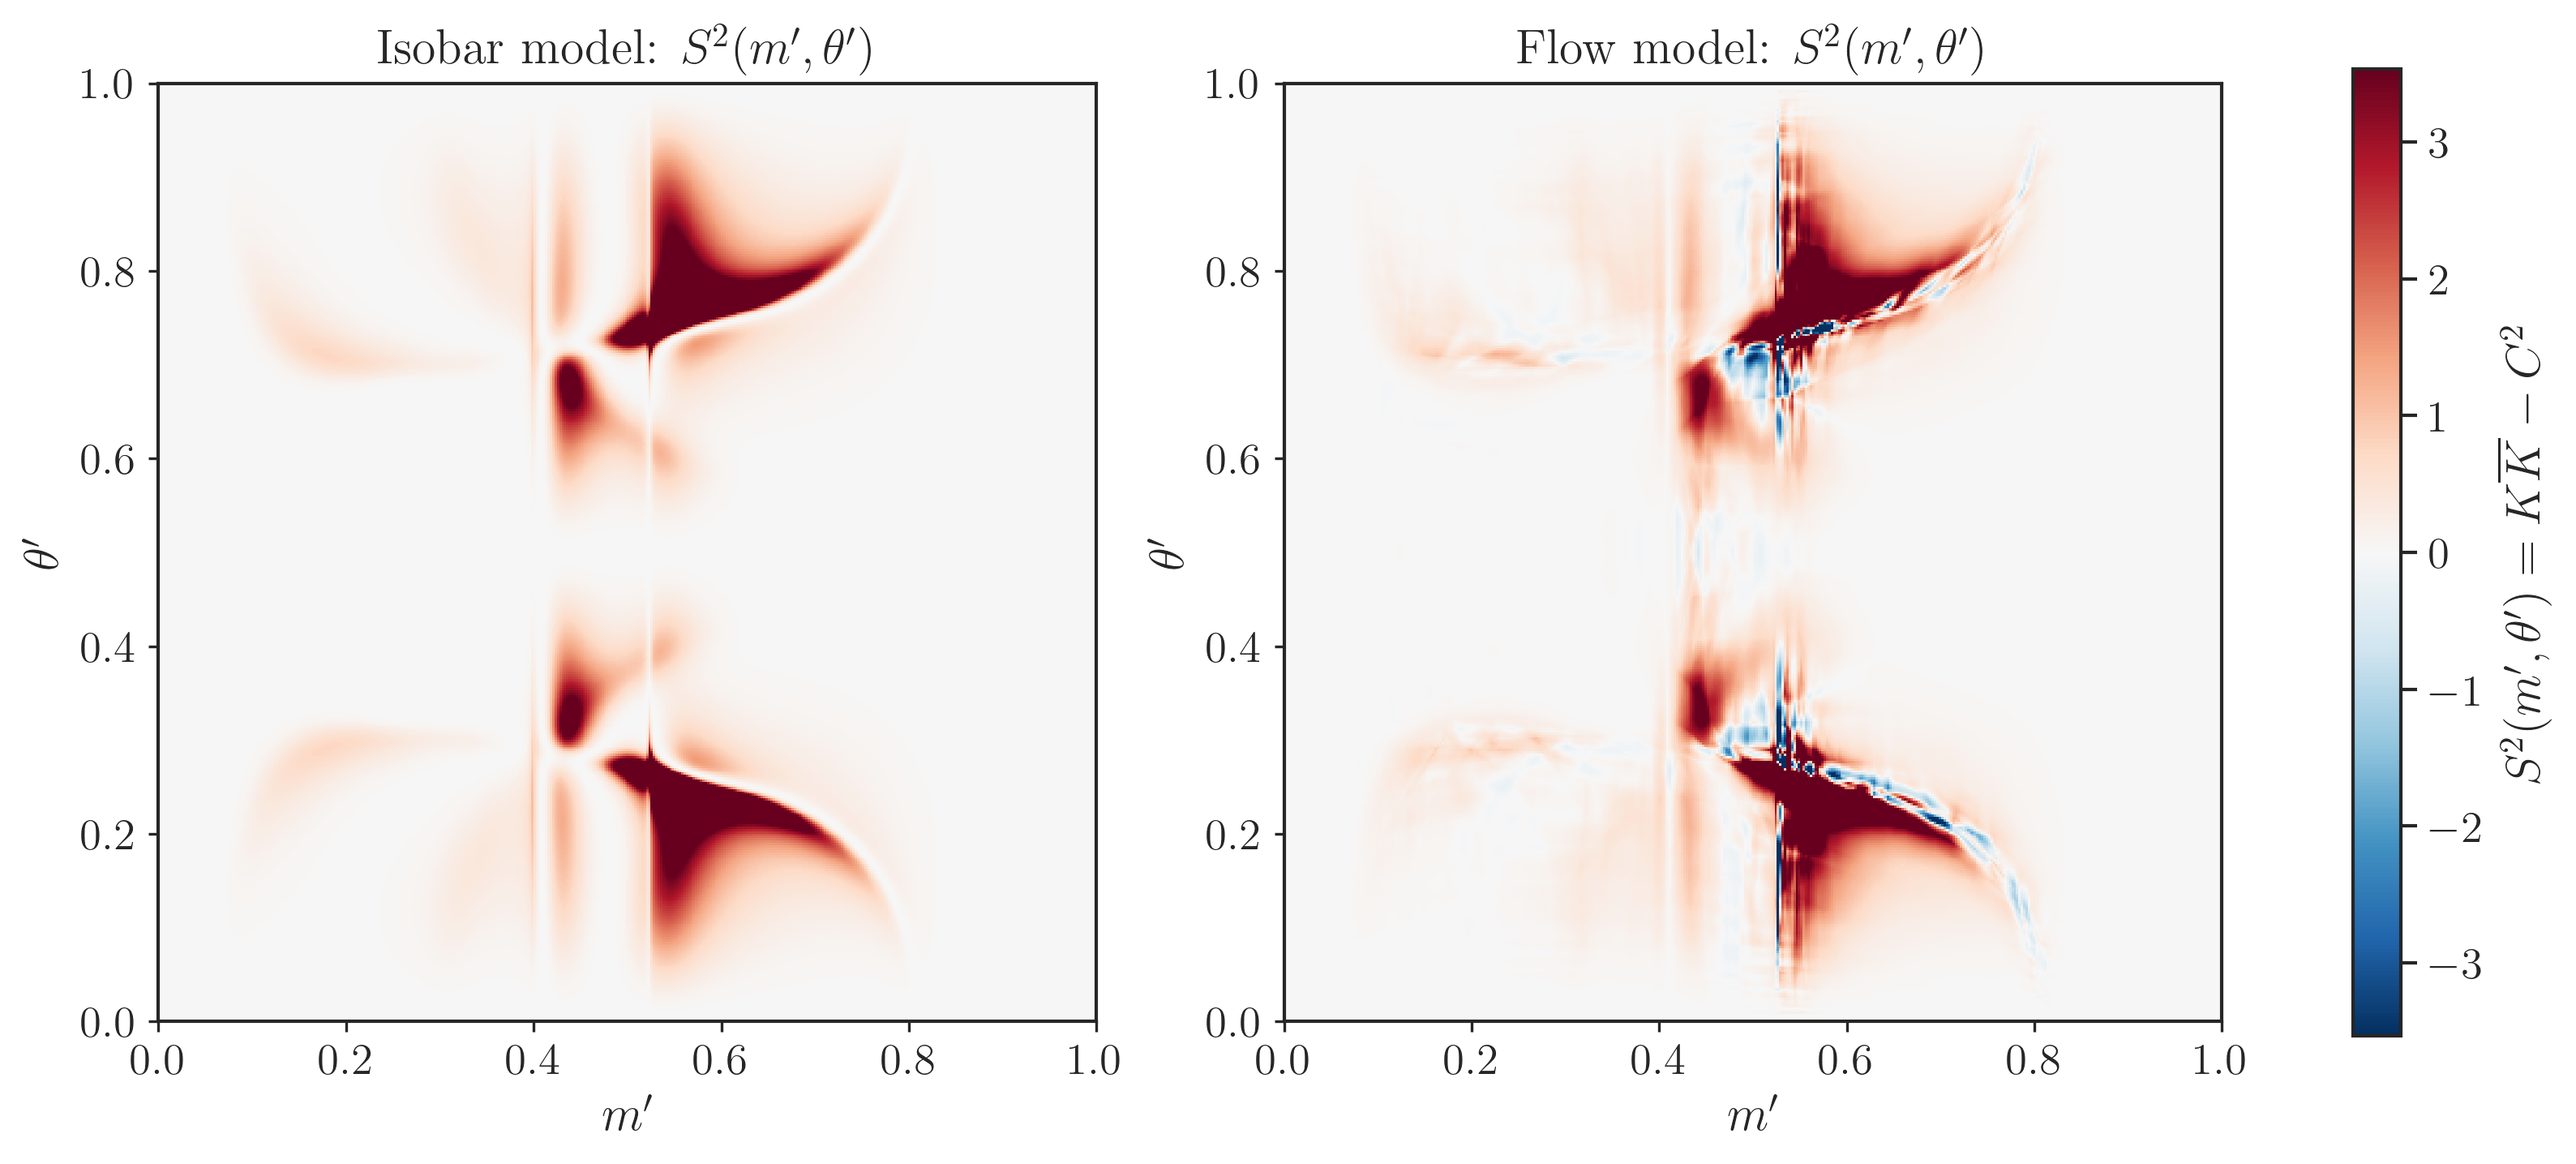

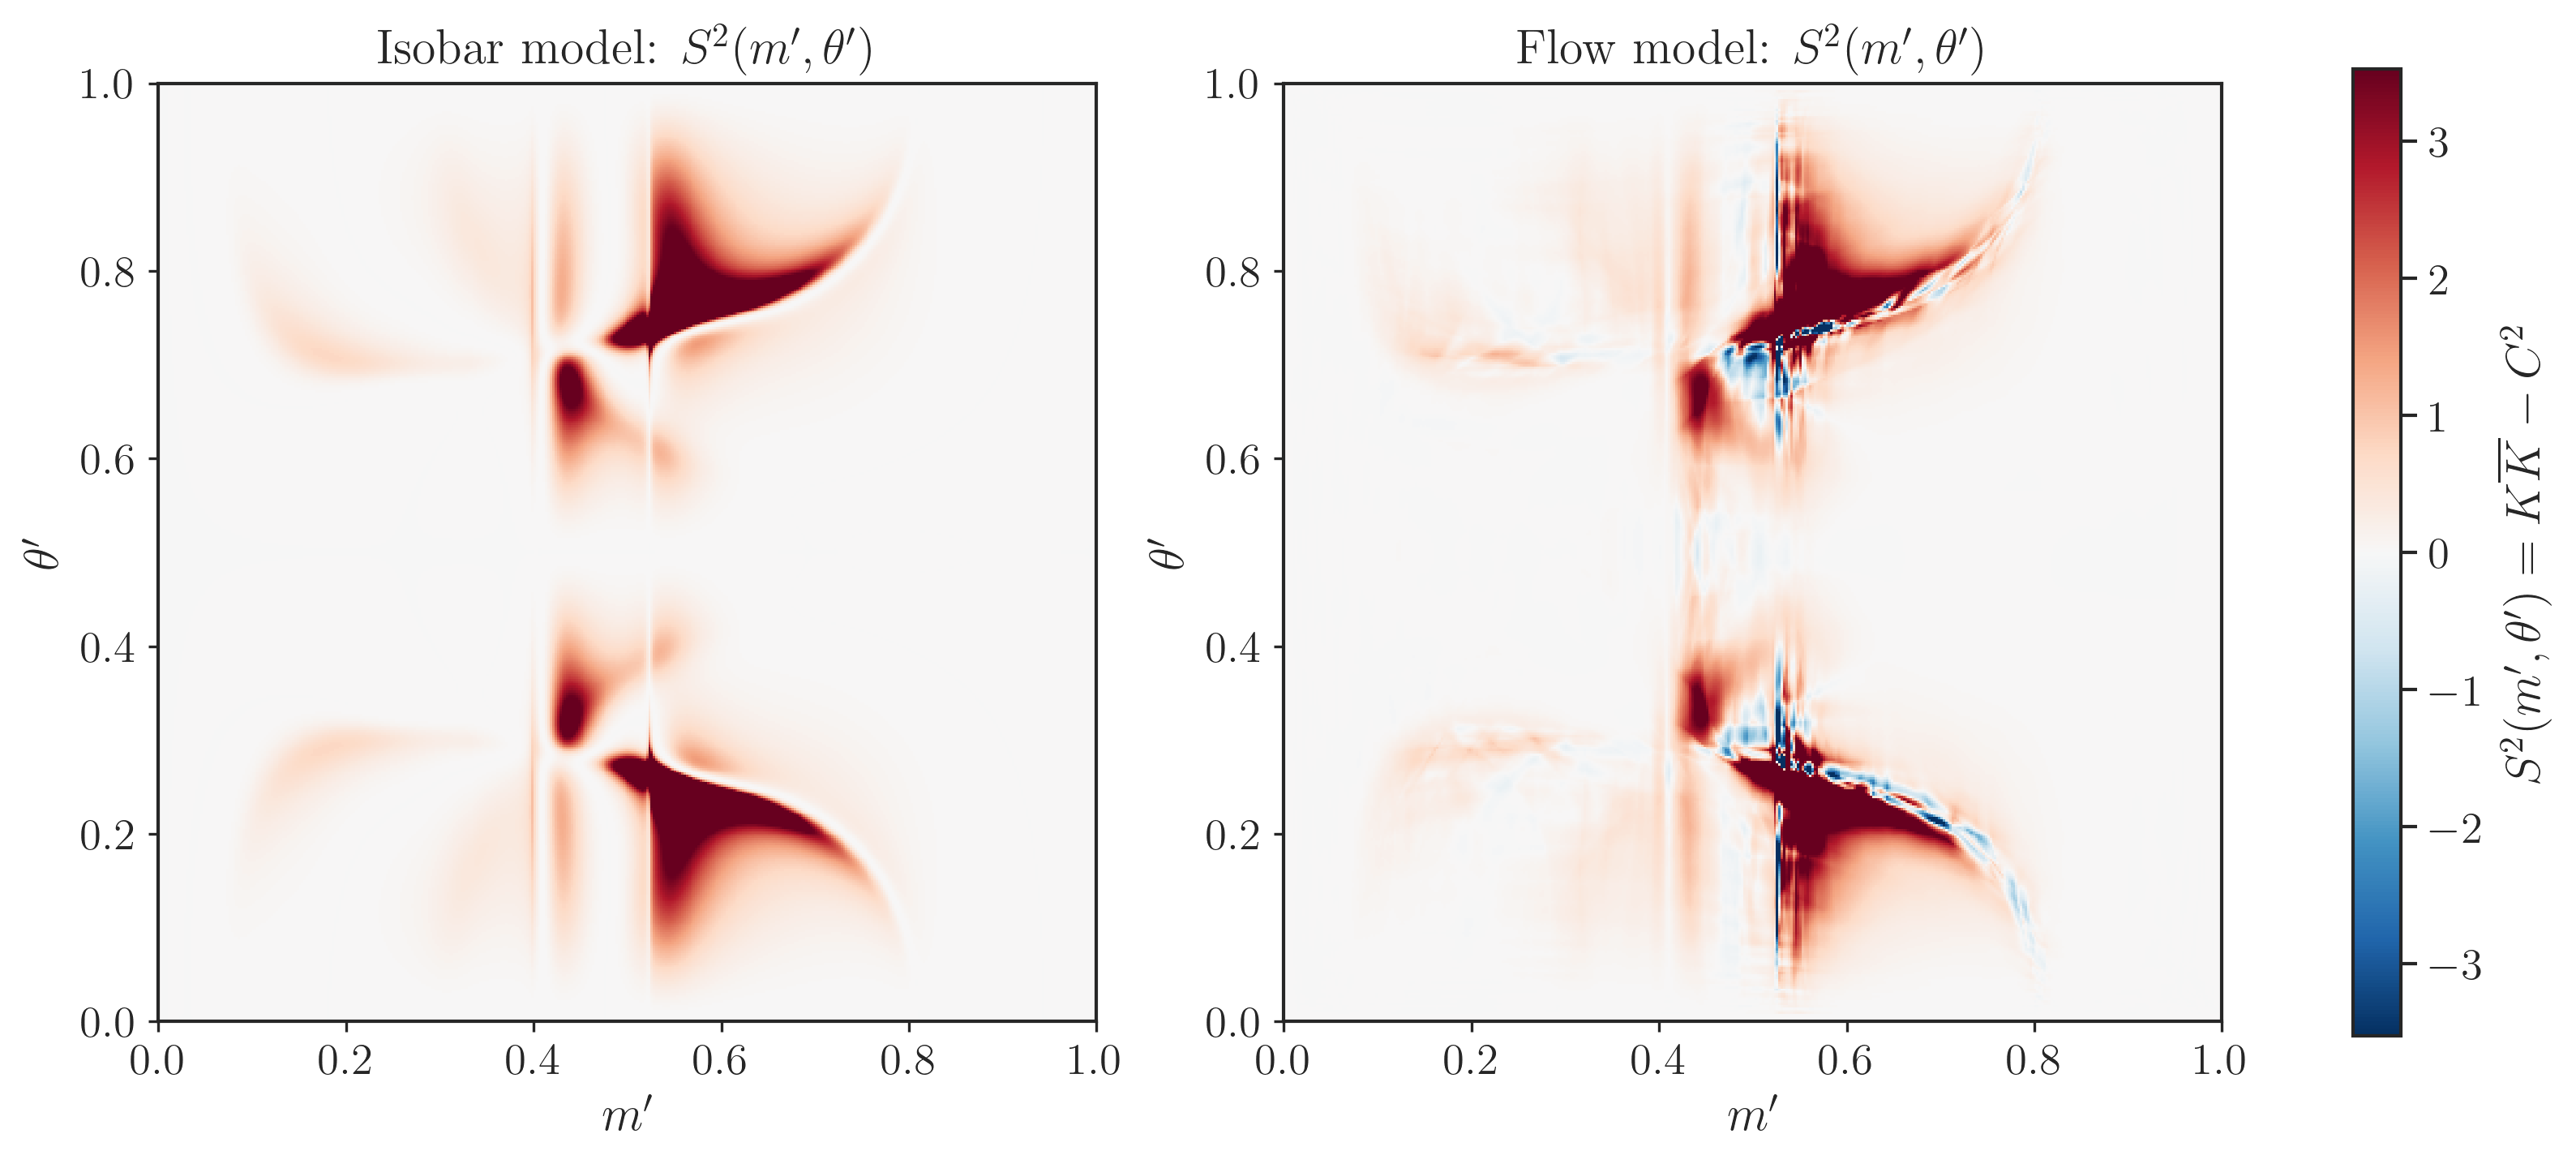

In [75]:
plot_S2_comparison_density(
    S2_exact=S2_exact_img,
    S2_flow=S2_flow_img,
    extent=(0.0, 1.0, 0.0, 1.0),
    savepath='S2_comparison_mtheta_symmetric.pdf',
)
